In [ ]:
7.날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명? [프로젝트]

In [ ]:
시각화 요구사항이 정확하게 이루어졌는가? 각 프로젝트 진행 과정에서 요구하고 있는 데이터개수 시각화 및 예측결과 시각화를 모두 진행하였다.

In [ ]:
프로젝트 2의 회귀모델 예측정확도가 기준 이상 높게 나왔는가? RMSE 값 150 이하를 달성

# datetime 처리
# 추가: 요일 변수도 중요한 특징
train['weekday'] = train['datetime'].dt.weekday

# 특징 확장: weekday, season, holiday, workingday, weather 포함
features = ['year', 'month', 'day', 'hour', 'weekday', 'temp', 'humidity', 'windspeed',
            'season', 'holiday', 'workingday', 'weather']

# 타겟 로그 변환: RMSE 안정화
y = np.log1p(train['count'])

# RandomForestRegressor으로 모델 학습
model = RandomForestRegressor(
   n_estimators=300,   # 트리 개수
   max_depth=15,       # 트리 깊이
   random_state=42,
   n_jobs=-1
)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

#####RMSE 값 150이하 달성#####
출력값:
RMSE: 0.30160285473982085
###########################

In [ ]:
프로젝트 1의 회귀모델 예측정확도가 기준 이상 높게 나왔는가? MSE 손실함수값 3000 이하를 달성
#학습률을 높이면 손실률을 줄일 수 있음
LEARNING_RATE = 0.1 #0.001

In [ ]:
프로젝트 1 : 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

In [3]:
#(1) 데이터 가져오기
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [4]:
#(2) 모델에 입력할 데이터 X 준비하기
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [5]:
#(3) 모델에 예측할 데이터 y 준비하기
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [6]:
#(4) train 데이터와 test 데이터로 분리하기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [7]:
# (5) 모델 준비하기
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [8]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [9]:
#(6) 손실함수 loss 정의하기
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [10]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [11]:
#(7) 기울기를 구하는 gradient 함수 구현하기
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [12]:
#(8) 하이퍼 파라미터인 학습률 설정하기
#LEARNING_RATE = 0.001
#############################################
#학습률을 높이면 손실률을 줄일 수 있음
LEARNING_RATE = 0.1
#############################################

In [13]:
#(9) 모델 학습하기

#%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 1001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5375.0486
Iteration 200 : Loss 4873.4791
Iteration 300 : Loss 4500.5389
Iteration 400 : Loss 4219.5555
Iteration 500 : Loss 4004.7298
Iteration 600 : Loss 3837.8681
Iteration 700 : Loss 3706.1005
Iteration 800 : Loss 3600.2878
Iteration 900 : Loss 3513.9095
Iteration 1000 : Loss 3442.2858


In [14]:
#(10) test 데이터에 대한 성능 확인하기
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(3089.9903861265675)

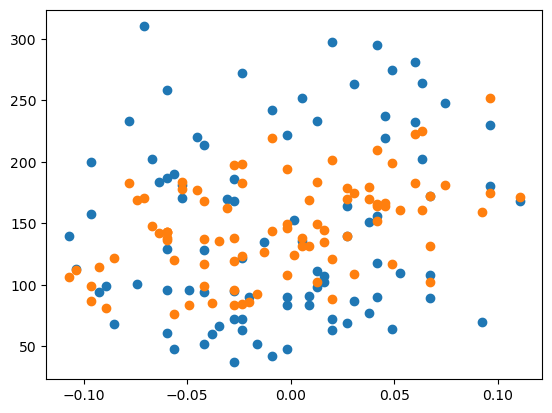

In [15]:
#(11) 정답 데이터와 예측한 데이터 시각화하기
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

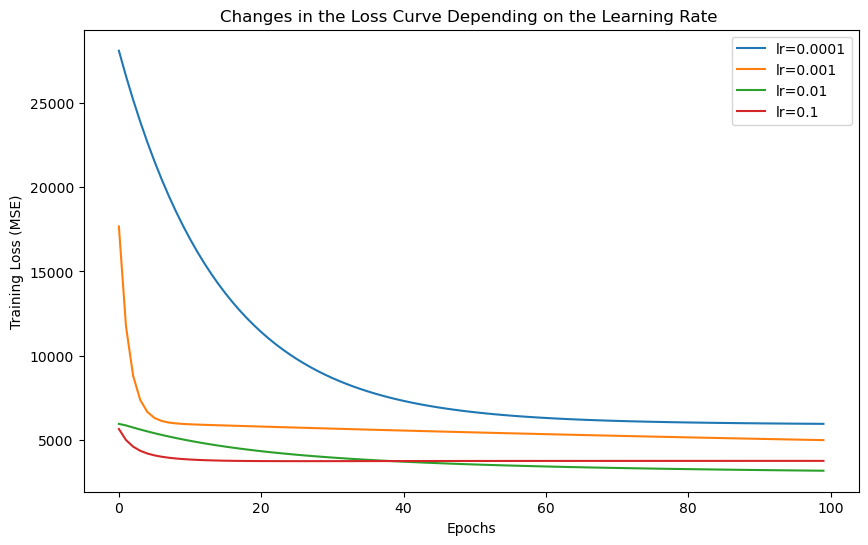

In [31]:
#############################################
# Changes in the Loss Curve Depending on the Learning Rate 

# 학습률 후보
learning_rates = [0.0001, 0.001, 0.01, 0.1]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    model = SGDRegressor(learning_rate="constant", eta0=lr, max_iter=1, tol=None, random_state=42)
    
    losses = []
    for epoch in range(100):
        model.partial_fit(X_train, y_train)
        y_pred = model.predict(X_train)
        loss = np.mean((y_train - y_pred) ** 2)
        losses.append(loss)
    
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Training Loss (MSE)")
plt.title("Changes in the Loss Curve Depending on the Learning Rate ")
plt.legend()
plt.show()
#############################################

In [ ]:
프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?

In [17]:
#(1) 데이터 가져오기
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [18]:
#(2) datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second
#############################################
# datetime 처리
# 추가: 요일 변수도 중요한 특징
train['weekday'] = train['datetime'].dt.weekday
#############################################

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

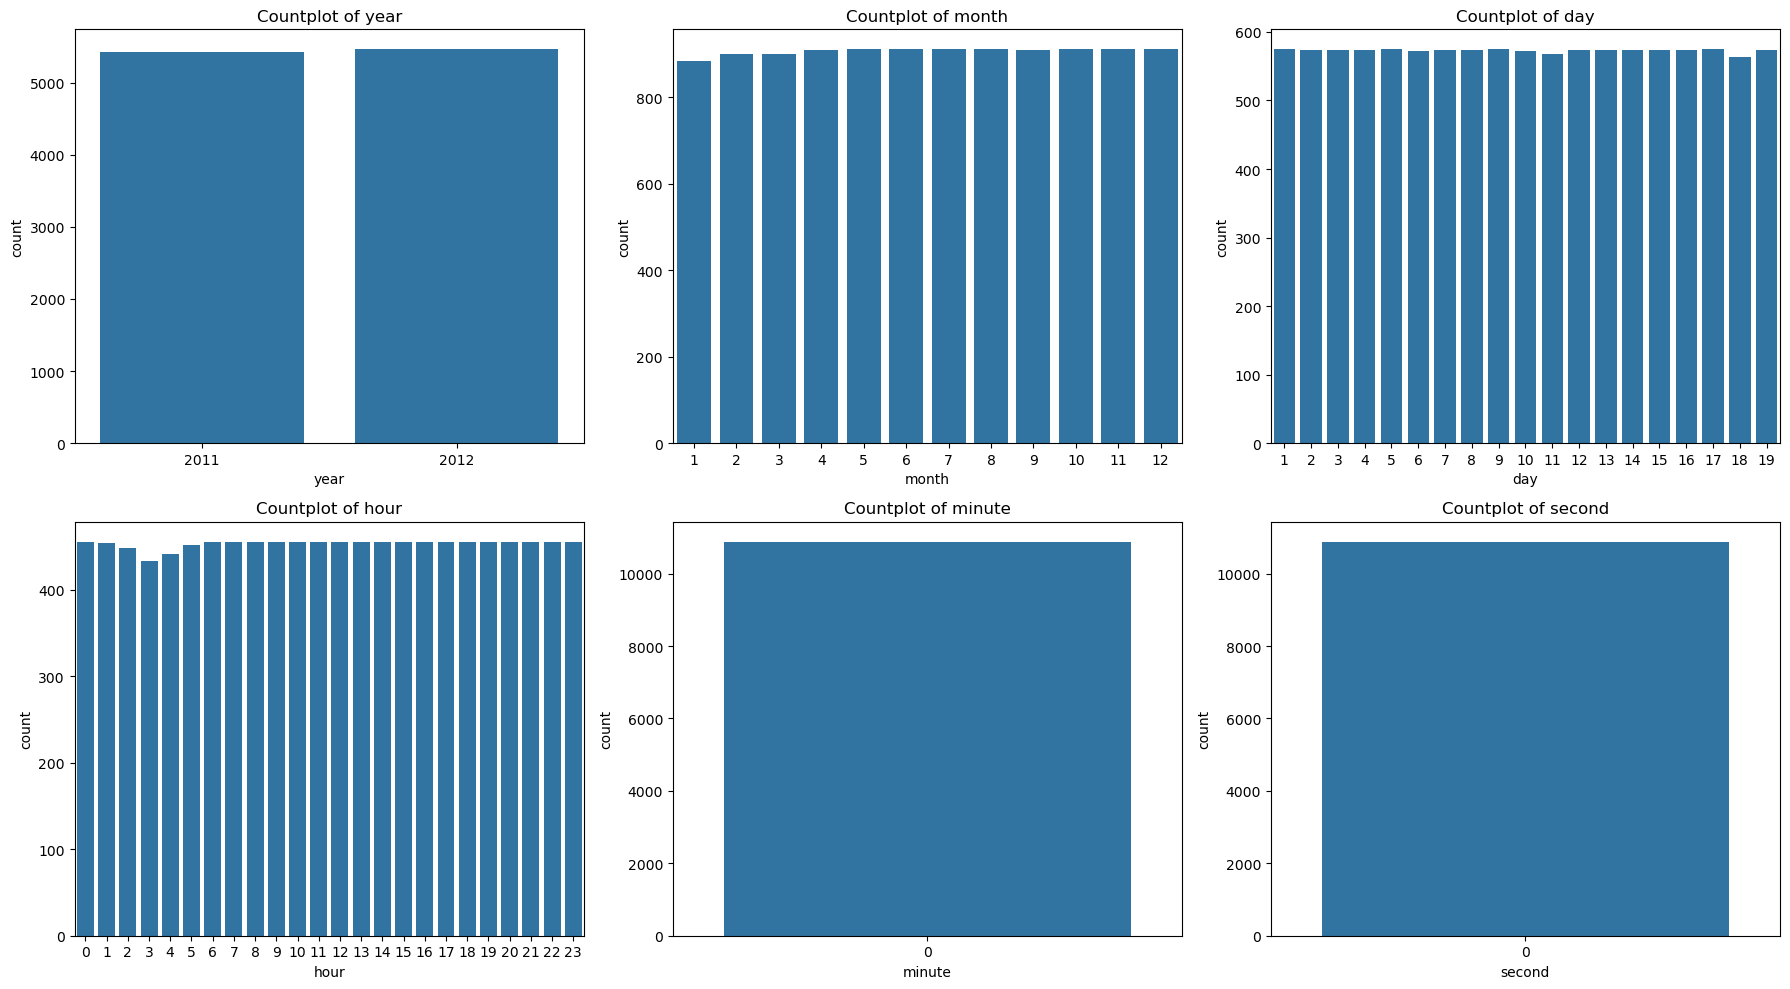

In [19]:
#(3) year, month, day, hour, minute, second 데이터 개수 시각화하기
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [20]:
#(4) X, y 컬럼 선택 및 train/test 데이터 분리
#############################################
#features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']

# 특징 확장: weekday, season, holiday, workingday, weather 포함
features = ['year', 'month', 'day', 'hour', 'weekday', 'temp', 'humidity', 'windspeed',
            'season', 'holiday', 'workingday', 'weather']
#############################################

X = train[features]
#############################################
# y = train['count']

#from sklearn.model_selection import train_test_split

# 타겟 로그 변환: RMSE 안정화
y = np.log1p(train['count'])
#############################################
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
#(5) LinearRegression 모델 학습
#############################################
#from sklearn.linear_model import LinearRegression
#기존 LinearRegression → RandomForestRegressor 선언
from sklearn.ensemble import RandomForestRegressor

#model = LinearRegression()
model = RandomForestRegressor(
   n_estimators=300,   # 트리 개수
   max_depth=15,       # 트리 깊이
   random_state=42,
   n_jobs=-1
)
#############################################
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
#(6) 학습된 모델로 X_test에 대한 예측값 출력 및 손실함수값 계산
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
#############################################
#mse = mean_squared_error(y_test, y_pred)
#rmse = np.sqrt(mse)
#print("MSE:", mse)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#############################################
print("RMSE:", rmse)

RMSE: 0.30160285473982085


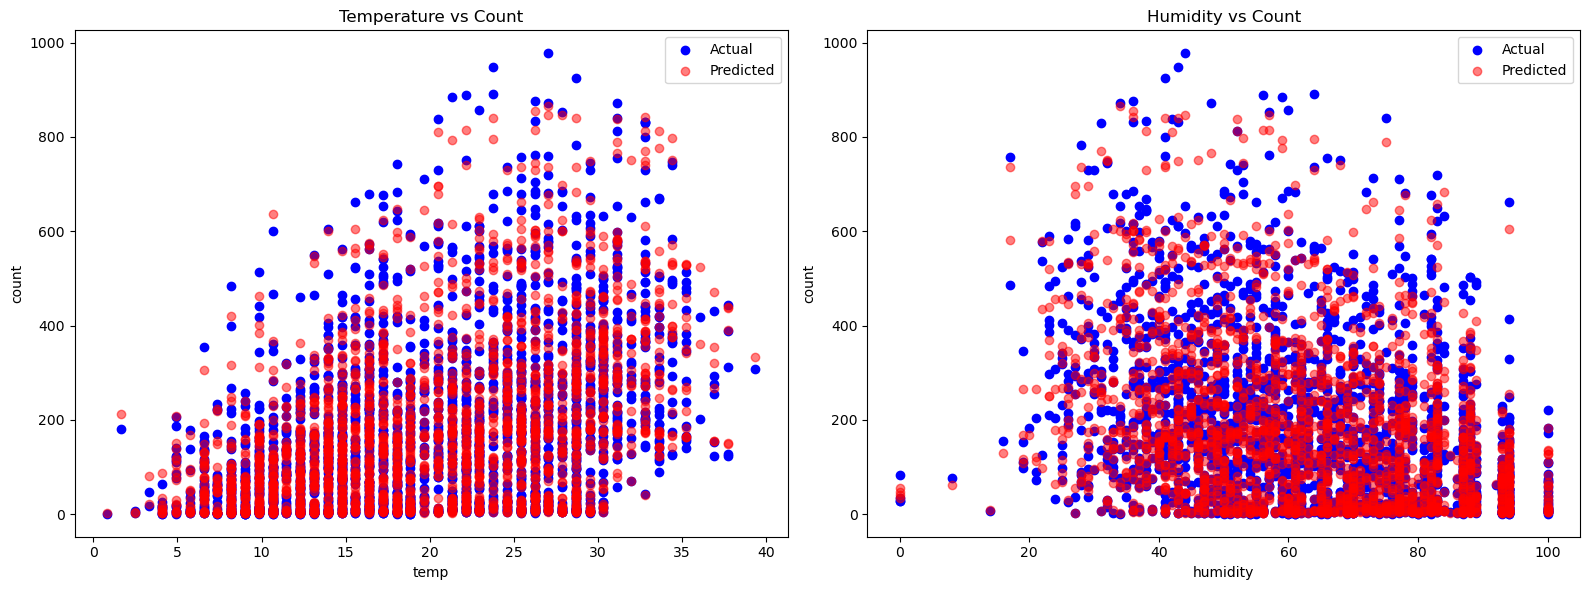

In [25]:
#(7) x축은 temp 또는 humidity로, y축은 count로 예측 결과 시각화하기
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
#############################################
#axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
#axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].scatter(X_test['temp'], np.expm1(y_test), color='blue', label='Actual')
axs[0].scatter(X_test['temp'], np.expm1(y_pred), color='red', label='Predicted', alpha=0.5)
#############################################
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
#############################################
#axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
#axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].scatter(X_test['humidity'], np.expm1(y_test), color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], np.expm1(y_pred), color='red', label='Predicted', alpha=0.5)
#############################################
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()
#############################################
plt.tight_layout()
plt.show()
#############################################